# **Graph Analysis**

**Dataset: StarPep (sequences from 10 to 100 amino acids)**

In [8]:
import pandas as pd
import sys
import os
from plot import (
    plot_inter_amino_acid_distances,
    create_merge_similarity_matrix, 
    plot_merge_similarity_matrix, 
    plot_density, 
    statistics
)

base_path = 'data/StarPep/Thesis/Analysis-2024-08-08T19.42.27/Graph_Analysis/'
output_base_path = 'output/StarPep/Interval-old/'

## **Inter-amino acid distances**

### **Statistics**

In [2]:
distance_functions = [
    'euclidean', 'angular_separation', 'bhattacharyya', 'canberra', 
    'clark', 'lance_williams', 'soergel'
]
output_filepath = f'{output_base_path}Statistics.csv'
percentiles = [0.05, 0.10, 0.25, 0.50, 0.75]

stats_by_function = statistics(base_path, distance_functions, output_filepath, percentiles)
stats_by_function.head(7)

Processing distance functions: 100%|██████████| 7/7 [01:01<00:00,  8.72s/it]


,distance_function,count,mean,std,min,5%,10%,25%,50%,75%,max
0,angular_separation,25688944.0,0.131011,0.164412,1.000000e-08,0.002314,0.005056,0.018027,0.065390,0.179948,1.000000
1,bhattacharyya,25688946.0,2.737850,1.620385,9.118815e-02,0.682574,0.913923,1.515764,2.430412,3.645232,20.357421
2,canberra,25688946.0,1.085541,0.597095,1.253596e-02,0.250210,0.355414,0.615481,1.014184,1.471174,3.000000
3,clark,25688946.0,0.707474,0.361186,1.008155e-02,0.169155,0.240433,0.416101,0.681320,0.983046,1.732051
4,euclidean,25688946.0,20.126474,13.689747,7.187550e-01,4.998717,5.886966,10.283634,16.613239,26.241980,254.056279
5,lance_williams,25688946.0,0.339796,0.203929,5.685700e-03,0.072633,0.102025,0.178902,0.304133,0.465998,1.000000
6,soergel,25688946.0,0.474613,0.217372,1.130712e-02,0.135429,0.185159,0.303506,0.466414,0.635742,1.000000


### **Distributions**

#### **Angular separation**

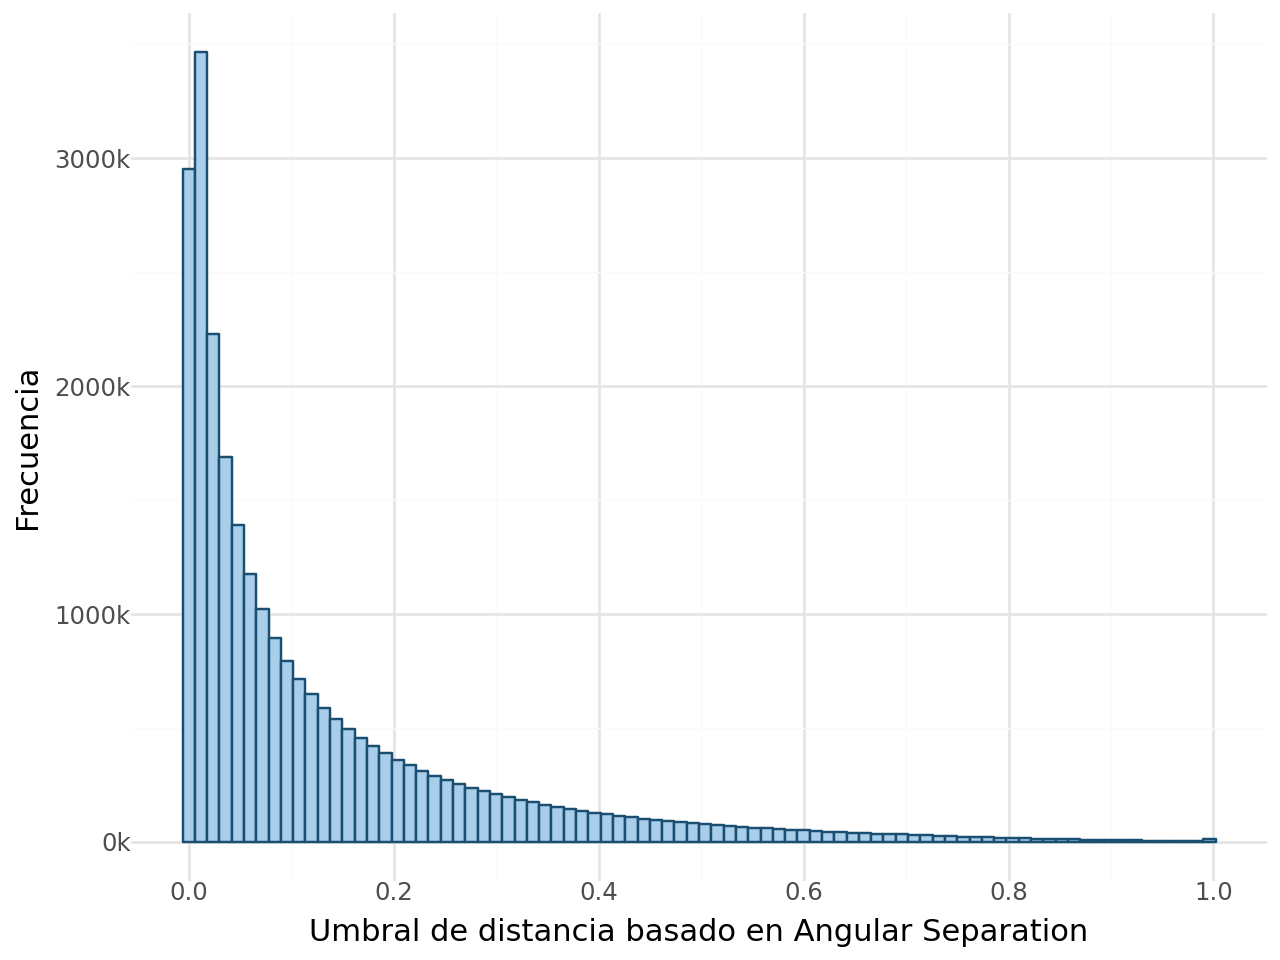

In [13]:
distance_function = 'angular_separation'
x_axis_step = 0.2 
binwidth = 0.012

distances_filepath = f'{base_path}Inter_Amino_Acid_Distances-{distance_function}.csv'
output_filepath = f'{output_base_path}Inter_Amino_Acid_Distances-{distance_function}.png'
plot_inter_amino_acid_distances(distances_filepath, distance_function, x_axis_step, binwidth, output_filepath)

#### **Bhattacharyya**

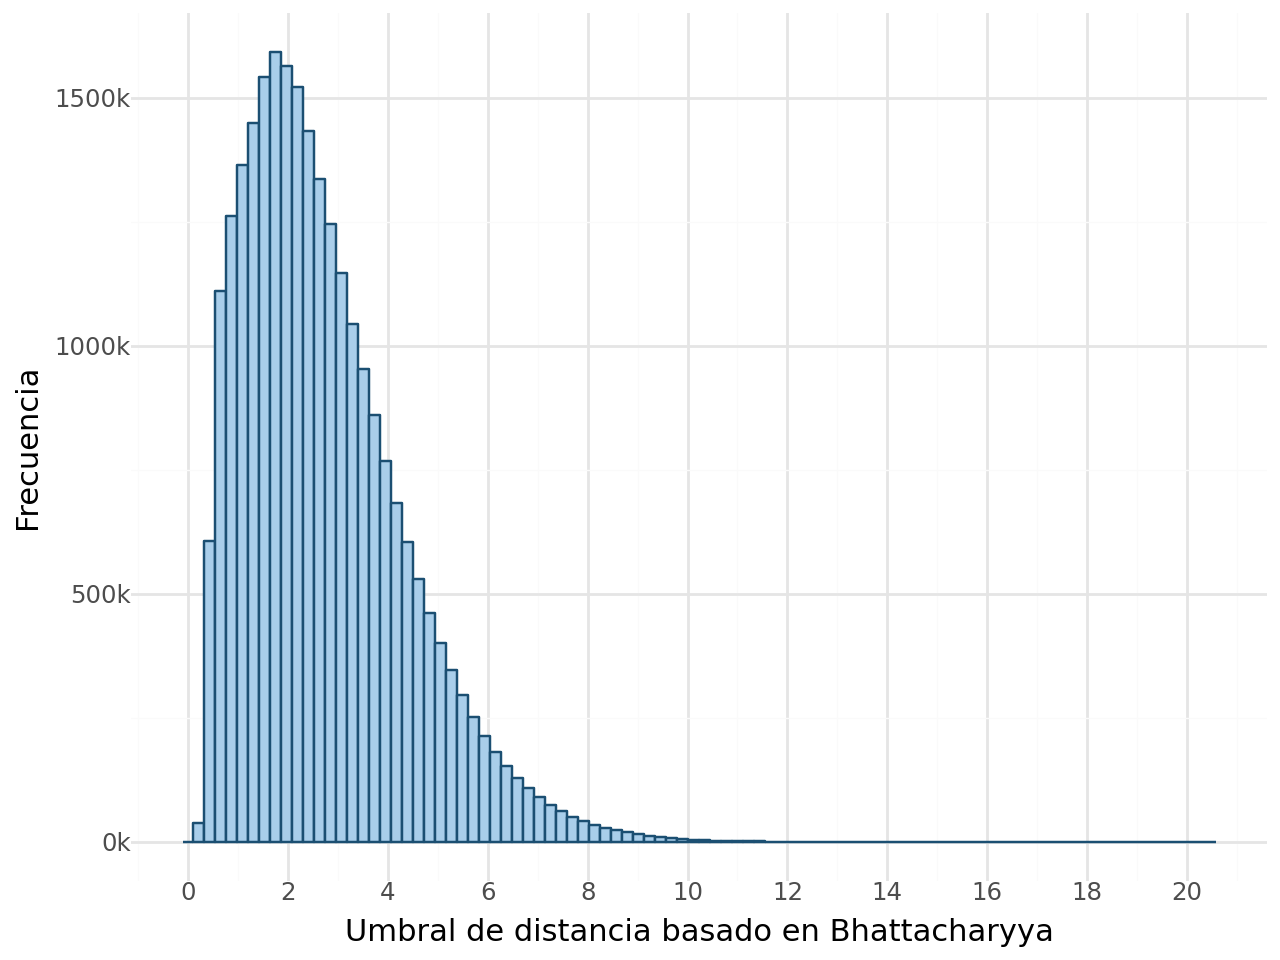

In [14]:
distance_function = 'bhattacharyya'
x_axis_step = 2
binwidth = 0.22

distances_filepath = f'{base_path}Inter_Amino_Acid_Distances-{distance_function}.csv'
output_filepath = f'{output_base_path}Inter_Amino_Acid_Distances-{distance_function}.png'
plot_inter_amino_acid_distances(distances_filepath, distance_function, x_axis_step, binwidth, output_filepath)

#### **Canberra**

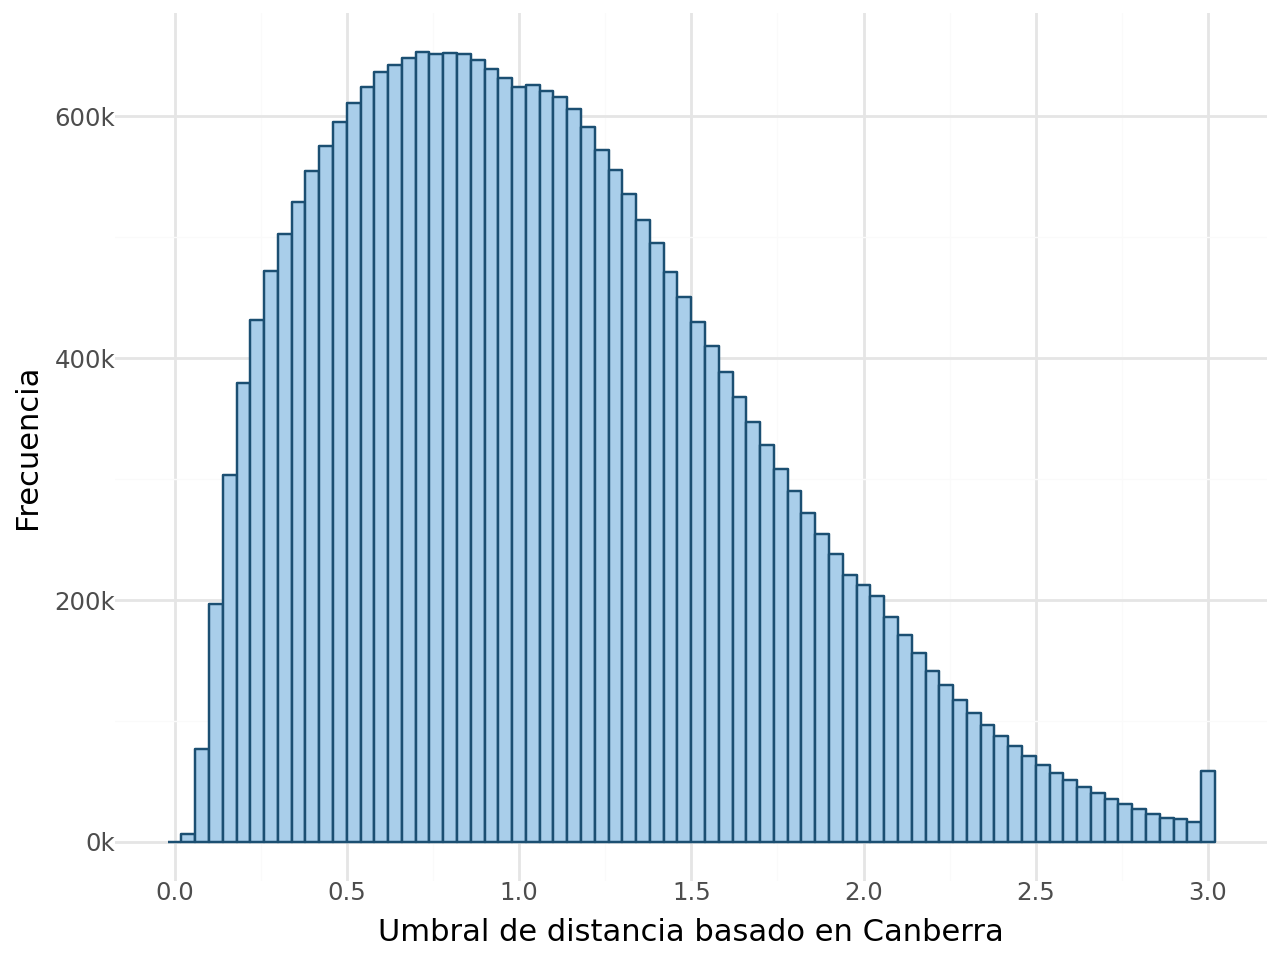

In [15]:
distance_function = 'canberra'
x_axis_step = 0.5
binwidth = 0.04

distances_filepath = f'{base_path}Inter_Amino_Acid_Distances-{distance_function}.csv'
output_filepath = f'{output_base_path}Inter_Amino_Acid_Distances-{distance_function}.png'
plot_inter_amino_acid_distances(distances_filepath, distance_function, x_axis_step, binwidth, output_filepath)

#### **Clark**

In [6]:
distance_function = 'clark'
x_axis_step = 0.5
binwidth = 0.025

distances_filepath = f'{base_path}Inter_Amino_Acid_Distances-{distance_function}.csv'
output_filepath = f'{output_base_path}Inter_Amino_Acid_Distances-{distance_function}.png'
#plot_inter_amino_acid_distances(distances_filepath, distance_function, x_axis_step, binwidth, output_filepath)

#### **Euclidean**

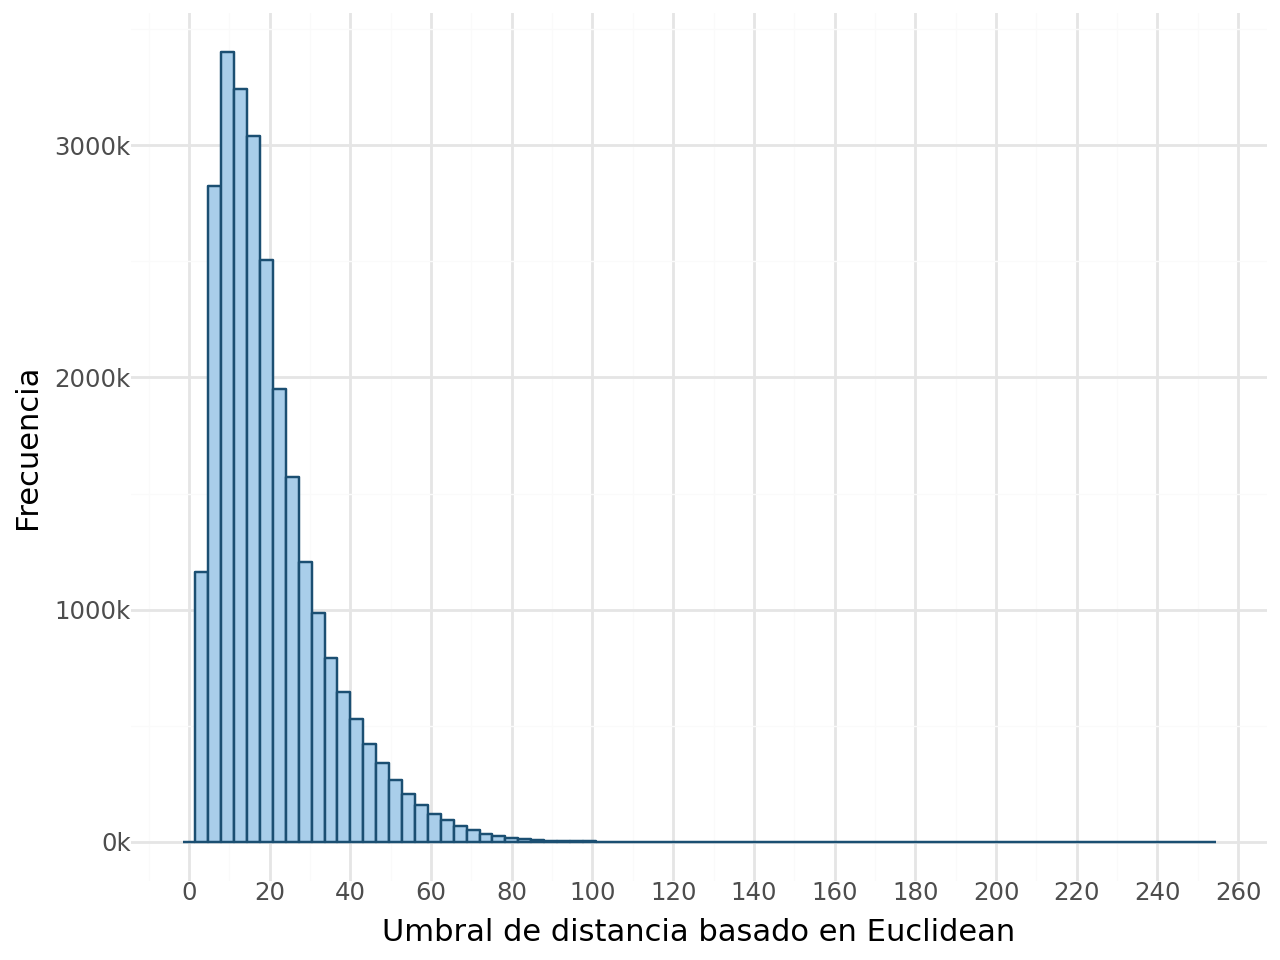

In [16]:
distance_function = 'euclidean'
x_axis_step = 20
binwidth = 3.2

distances_filepath = f'{base_path}Inter_Amino_Acid_Distances-{distance_function}.csv'
output_filepath = f'{output_base_path}Inter_Amino_Acid_Distances-{distance_function}.png'
plot_inter_amino_acid_distances(distances_filepath, distance_function, x_axis_step, binwidth, output_filepath)

#### **Lance Williams**

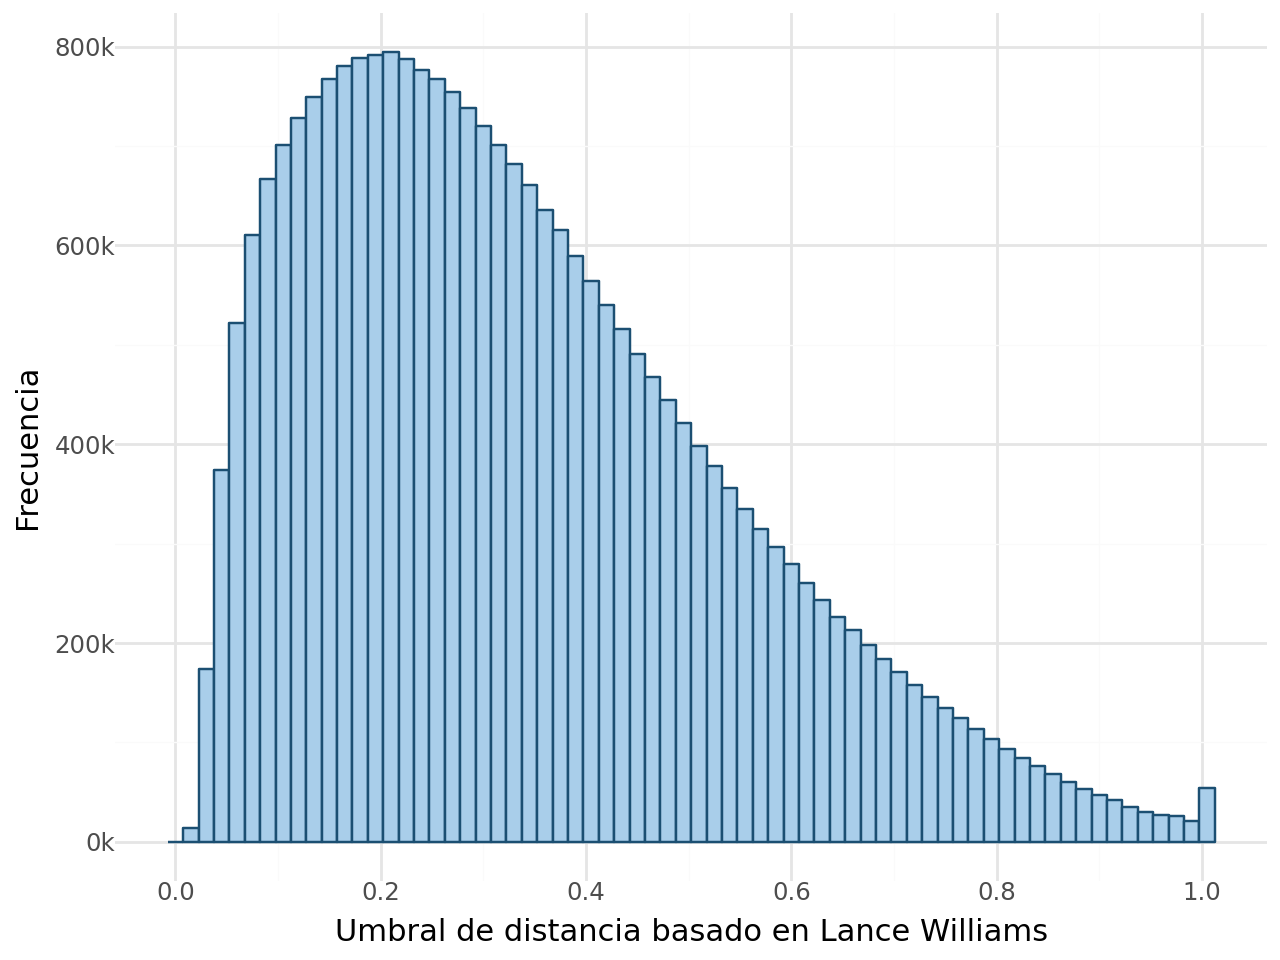

In [17]:
distance_function = 'lance_williams'
x_axis_step = 0.2
binwidth = 0.015

distances_filepath = f'{base_path}Inter_Amino_Acid_Distances-{distance_function}.csv'
output_filepath = f'{output_base_path}Inter_Amino_Acid_Distances-{distance_function}.png'
plot_inter_amino_acid_distances(distances_filepath, distance_function, x_axis_step, binwidth, output_filepath)

#### **Soergel**

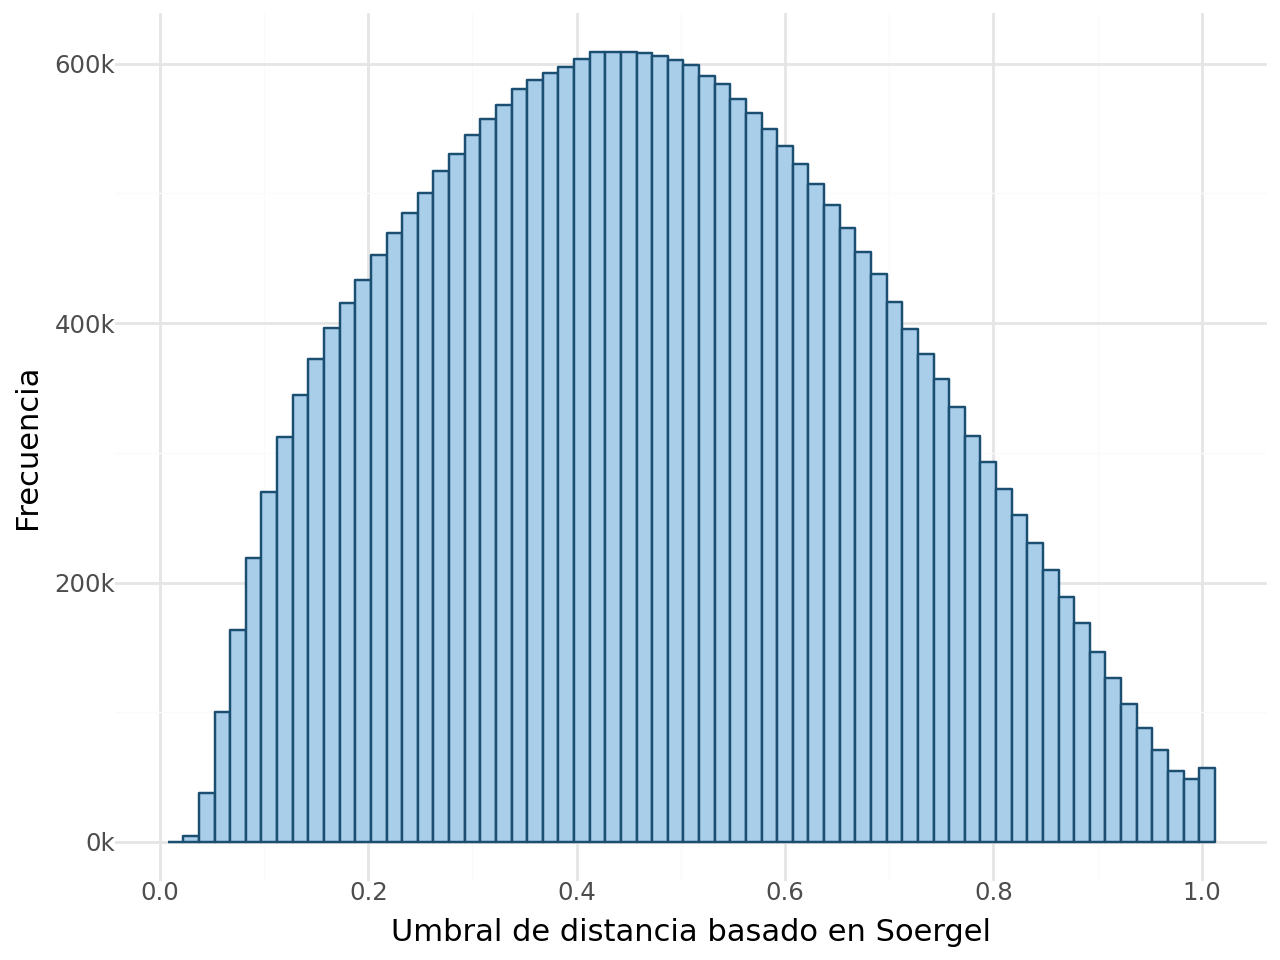

In [18]:
distance_function = 'soergel'
x_axis_step = 0.2
binwidth = 0.015

distances_filepath = f'{base_path}Inter_Amino_Acid_Distances-{distance_function}.csv'
output_filepath = f'{output_base_path}Inter_Amino_Acid_Distances-{distance_function}.png'
plot_inter_amino_acid_distances(distances_filepath, distance_function, x_axis_step, binwidth, output_filepath)

## **Edges analysis**

### **Graph density** 

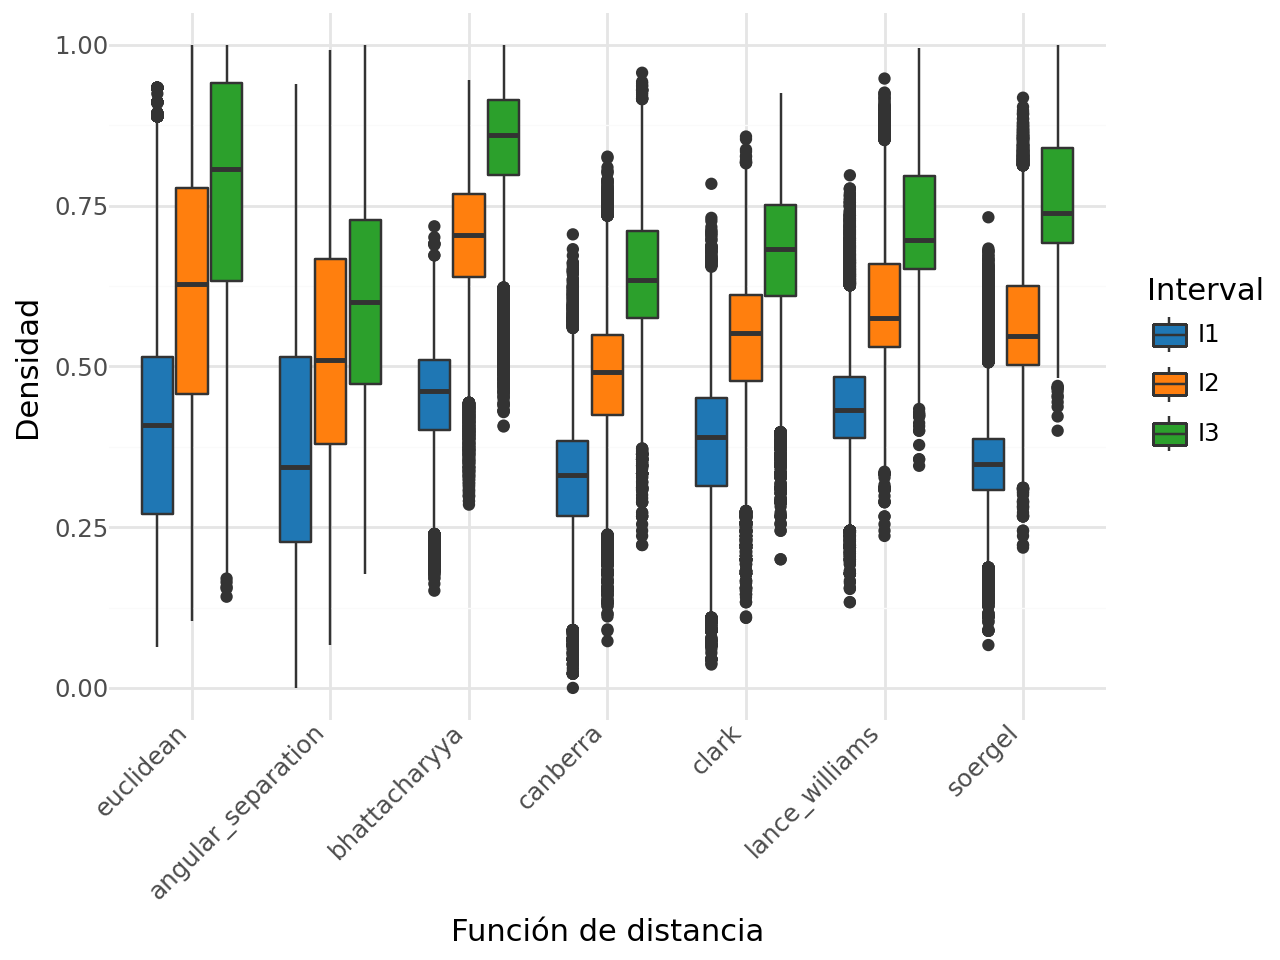

In [9]:
input_filepath = f'{base_path}Graph-information.csv'
output_filepath = f'{output_base_path}Density_per_Distance_Function.png'
plot, graph_info = plot_density(input_filepath, output_filepath)
plot.show()

### **Empty graph**

In [11]:
zero_edges = graph_info[graph_info['number_of_edges'] == 0]
count_zero_edges = zero_edges.groupby(['distance_function', 'interval'], observed=True).size()
count_zero_edges.head(10)

distance_function   interval
angular_separation  I1          1
canberra            I1          1
dtype: int64

NameError: name 'graph_info' is not defined

### **Edge statistics**

In [12]:
percentiles = [0.05, 0.10, 0.25, 0.50, 0.75]
edge_stats_by_function = graph_info.groupby('distance_function', observed=True)['number_of_edges'].describe(percentiles=percentiles)
edge_stats_by_function.head(7)

,count,mean,std,min,5%,10%,25%,50%,75%,max
distance_function,,,,,,,,,,
euclidean,103908.0,316.723380,399.544931,21.0,38.0,45.0,74.0,160.0,395.0,3666.0
angular_separation,103908.0,366.994178,544.091193,0.0,18.0,27.0,52.0,136.0,409.0,4681.0
bhattacharyya,103908.0,449.602764,625.779727,14.0,34.0,43.0,73.0,180.0,530.0,4642.0
canberra,103908.0,404.400373,625.270139,0.0,18.0,24.0,45.0,127.0,441.0,4602.0
clark,103908.0,443.003705,673.966561,2.0,20.0,27.0,49.0,142.0,485.0,4561.0
lance_williams,103908.0,480.180910,717.925665,6.0,25.0,32.0,57.0,156.0,541.0,4866.0
soergel,103908.0,457.882444,704.860692,3.0,21.0,29.0,53.0,145.0,500.0,4895.0
